# day02 今日工作目标：
·面向对象基础-类与对象
·继承与方法重写
·日期和时间
·多线程变成
·git的使用

## 0.昨日回顾
变量、函数（形参类型）、语句、匿名函数、列表推导式、装饰器、文件管理、主程序入口的完成代码

## 1.综合项目目标：
用面向对象设计多个ai模型，用多线程模拟多个用户同时提交任务，用datetime记录每个任务耗时，最后分析不同并发方式的性能差异。
git和github，进行代码管理的基础操作

## 2. 面向对象基础--类与对象
### 2.1 为甚么要学习面向对象？
一批汽车，“特征”：品牌，颜色，速度，“动作”：跑，刹车
无面向对象，定义一辆车，一堆变量和函数，杂乱无章

In [ ]:
car1_color = "红色"
car1_brand = "byd"
car1_spedd = 80

def car1_run():
    pass

car2_color = "红色"
car2_brand = "byd"
car2_spedd = 80

def car1_run():
    pass    

面向对象：画一张图纸，特征和动作定义，“类（Class）”，拿着这个图纸造一个具体的车，“对象（Object）”

## 2.2 定义第一个类
用classin关键字来定义类，类的首字母需要是大写;创造对象或者实例化对象

In [2]:
class Car:
    pass

In [3]:
my_car = Car()   
print(my_car) #内置的__str__

## 2.3 类的属性和方法

In [ ]:
类属性 vs 实例属性

In [ ]:
class Car:
    wheel_count = 4   # 类属性：所有车都默认 4 个轮子

    def __init__(self, color, brand):
        self.color = color    # 实例属性：每辆车可以不一样

print(Car.wheel_count)   # 4，类属性可以直接用类名访问

In [4]:
class Car:
    def __init__(self, color, brand):
        self.color = color #把传进来的color存到对象身上
        self.brand = brand  #把传进来的brand存到对象身上

my_car = Car("红色", "byd")
print(my_car.color)
print(my_car.brand)

红色
byd


In [ ]:
1.self理解为当前这个对象资深，self.color = color 把这个对象的color属性设置为传进来的color值，每个对象都有自己的self，互不影响
2.__init__里面的参数，都是从创建对象时（）传进来

 ### 2.3.2方法：写在类里面的函数，用来描述对象能做什么

In [8]:
class Car:
    def __init__(self, color, brand):
        self.color = color #把传进来的color存到对象身上
        self.brand = brand  #把传进来的brand存到对象身上
        self.speed = 0

    def run(self, how_fast):
        self.speed = how_fast
        print(f"{self.color}的{self.brand}正在以{self.speed} km/h行驶")

    def stop(self):
        self.speed = 0
        print(f"{self.color}的{self.brand}停下来了")

    def mend(self):
        self.stop()

my_car = Car("红色", "byd")
my_car.run(60)
my_car.stop()


红色的byd正在以60 km/h行驶
红色的byd停下来了


In [ ]:
注意：方法的第一个参数永远是self，但调用时不需要自己传，python会自动把对象本身塞进去。

### 2.3.3 类里面函数的分类

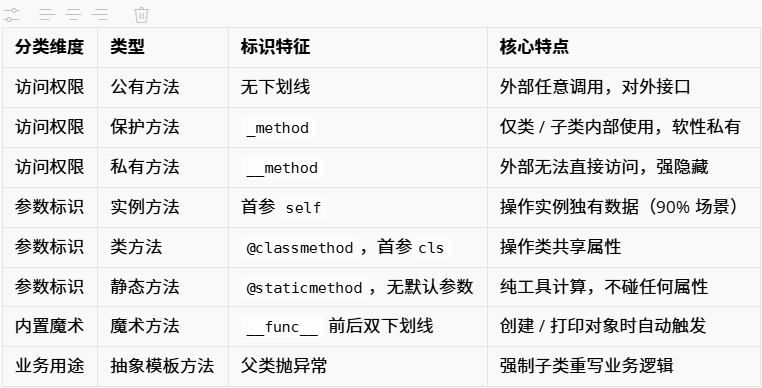

In [ ]:
1.按权限分类
1.1 公有方法（无下划线）
定义：方法名不加_,外部代码可只有调用，是对外提供的功能接口

2.保护方法(单下划线_xxx)
约定：仅限本类、子类内部使用，外部不建议调用，语法不强制拦截

3.私有方法(双下划线__xxx)
外部、子类无法访问，完全用于内部底层逻辑

2. 按照第一个参数区分
   
2.1 实例方法：最常见

特征：第一个固定参数self，只能用实例调用

2.2 类方法@classmethod

装饰器，第一个参数cls，代表整个类，只能操作类属性，不能访问实例独有的数据


In [25]:
class Car:
    wheel_count = 4   # 类属性：所有车都默认 4 个轮子

    def __init__(self, color, brand):
        self.color = color    # 实例属性：每辆车可以不一样

    @classmethod
    def print_total(wheel_count):
        print(f"车论数：{cls.wheel_counts}")

my_car = Car("red","byd")
print(Car.wheel_count)   # 4，类属性可以直接用类名访问
print(my_car.wheel_count)

4
4


In [ ]:
2.3 静态方法@staticmethod
特征：无默认参数，不用self和cls去调用；和类，实例都无关，只是挂靠在类里面的一个工具函数
@staticmethod

def calc_tool(a,b):
    return a+b


In [ ]:
3. 特殊内置方法：
系统自动触发的
def __init__(self,color)
def __str__(self)

随堂作业：

定义一个student类，有姓名和年龄两个属性（实例属性），老师名字的类属性，有一个introduce方法，能够打印“我叫xx，今年xx岁，我的老师叫xxx”。创造2个学生对象并且让他们自我介绍

In [37]:
class Student:
    #类属性
    teacher_name = "王老师"

    def __init__(self, name, age):
        self.name = name #实例属性
        self.age = age

    #1.实例方法
    def introduce(self):
        print(f"我叫{self.name}，今年{self.age}岁，老师：{Student.teacher_name}")
        print(f"我叫{self.name}，今年{self.age}岁，老师：{self.teacher_name}")

    #2. 类方法
    @classmethod
    def change_teacher(cls, new_teacher):
        #修改类属性，所有学生公用
        cls.teacher_name = new_teacher
        print(f"全班老师统一改为：{cls.teacher_name}")

    #3.静态方法:不能访问任何属性
    @staticmethod
    def show_tip():
        print("上课请认真听讲！")

    

s1 = Student("小明",12)
s1.introduce()
s2 = Student("小红",8)

# Student.change_teacher("李老师")
s1.change_teacher("李老师")
s1.introduce()
s2.introduce()

#静态方法的调用：类和对象都可以调用，不需要实例数据
Student.show_tip()
s1.show_tip()

我叫小明，今年12岁，老师：王老师
我叫小明，今年12岁，老师：王老师
全班老师统一改为：李老师
我叫小明，今年12岁，老师：李老师
我叫小明，今年12岁，老师：李老师
我叫小红，今年8岁，老师：李老师
我叫小红，今年8岁，老师：李老师
上课请认真听讲！
上课请认真听讲！


## 3.继承与重写
### 3.1 什么是继承？

In [40]:
class Car:
    def __init__(self, color, brand):
        self.color = color #把传进来的color存到对象身上
        self.brand = brand  #把传进来的brand存到对象身上
        self.speed = 0

    def run(self, how_fast):
        self.speed = how_fast
        print(f"{self.color}的{self.brand}正在以{self.speed} km/h行驶")

    def stop(self):
        self.speed = 0
        print(f"{self.color}的{self.brand}停下来了")

    def mend(self):
        self.stop()


#电动车继承Car
class ElectricCar(Car):
    def __init__(self, color, brand, battery):
        super().__init__(color, brand) #调用父类的初始化，把颜色品牌线设好
        self.battery = battery  #电动车独有:电池容量
    def charge(self):
        print(f"{self.brand}正在充电,电池容量{self.battery}kwh")

ec = ElectricCar("蓝色", "特斯拉", 75)
ec.run(100)
ec.charge()

蓝色的特斯拉正在以100 km/h行驶
特斯拉正在充电,电池容量75kwh


### 3.2 方法重写
父类不放适合子类，需要在子类中重新写一个同名方法，把父类的盖过去。

In [47]:
class Car:
    def energy_info(self):
        print("这辆车使用燃油")

class ElectricCar(Car):
    def energy_info(self):
        print("这辆车使用电能")

my_car = Car()
my_car.energy_info()


ec = ElectricCar()
ec.energy_info()


这辆车使用燃油
这辆车使用电能


In [ ]:
🎯 任务一（基础关，约 20 分钟）：定义"宠物"类

要求：

1. 定义一个 `Pet` 类，有属性：`name`（名字）、`species`（种类，如"猫""狗"）、`energy`（精力值，初始 100）。
2. 有方法 `play()`：玩一次精力值减 20，打印"XX玩得很开心，剩余精力XX"。如果精力已经为 0，打印"XX累坏了，玩不动了"。
3. 有方法 `eat()`：吃一次精力值加 30（上限 100），打印"XX吃饱了，精力恢复到XX"。
4. 创建两个宠物对象，分别玩几次、吃几次，观察精力值变化。


🎯 任务二（进阶关，约 25 分钟）：用继承做"工作犬"

要求：

1. 让 `WorkingDog` 继承 `Pet`，新增属性 `job`（工作类型，如"导盲""搜救"）。
2. 新增方法 `work()`：工作一次精力减 40，打印"XX（工作类型）执行任务，剩余精力XX"。精力不足 40 时打印"XX精力不足，无法执行任务"。
3. 重写 `play()`：工作犬玩的时候打印"XX虽然是工作犬，但也要放松一下"，精力照常减 20。
4. 创建一个工作犬对象，演示它工作、玩、吃饭的过程。


🎯 任务三（挑战关，约 30 分钟）：为综合项目预热——定义 AIModel 父类

要求（为下午综合项目铺路，先写骨架）：

1. 定义 `AIModel` 类，属性：`name`（模型名）、`model_type`（模型类型）。
2. 有方法 `predict(self, input_data)`：父类里只打印"XX模型收到输入：XX，但具体推理逻辑由子类实现"，并 `return "父类默认结果"`。
3. 定义子类 `TextModel`（文本模型），重写 `predict`：用 `time.sleep(1)` 模拟推理耗时 1 秒，打印"文本模型XX正在生成文本..."，返回 `f"生成的文本结果: {input_data}"`。
4. 定义子类 `ImageModel`（图像模型），重写 `predict`：用 `time.sleep(2)` 模拟推理耗时 2 秒，打印"图像模型XX正在识别图像..."，返回 `f"识别结果: {input_data}"`。
5. 分别创建一个文本模型和一个图像模型，调用 `predict`，打印返回结果。

In [1]:
class Pet:
    def __init__(self, name, species):
        self.name = name
        self.species = species
        self.energy = 100

    def play(self):
        if self.energy <= 0:
            print(f"{self.name}累坏了，玩不动了")
            return
        self.energy -= 20
        if self.energy < 0:
            self.energy = 0
        print(f"{self.name}玩得很开心，剩余精力{self.energy}")

    def eat(self):
        self.energy += 30
        if self.energy > 100:
            self.energy = 100
        print(f"{self.name}吃饱了，精力恢复到{self.energy}")


cat = Pet("咪咪", "猫")
dog = Pet("旺财", "狗")

cat.play()
cat.play()
cat.play()
cat.play()
cat.play()
cat.play()   # 这次该累坏了
cat.eat()
cat.play()

dog.eat()
dog.play()

咪咪玩得很开心，剩余精力80
咪咪玩得很开心，剩余精力60
咪咪玩得很开心，剩余精力40
咪咪玩得很开心，剩余精力20
咪咪玩得很开心，剩余精力0
咪咪累坏了，玩不动了
咪咪吃饱了，精力恢复到30
咪咪玩得很开心，剩余精力10
旺财吃饱了，精力恢复到100
旺财玩得很开心，剩余精力80


In [2]:
class WorkingDog(Pet):
    def __init__(self, name, job):
        super().__init__(name, "狗")   # 种类固定是狗
        self.job = job

    def work(self):
        if self.energy < 40:
            print(f"{self.name}精力不足，无法执行{self.job}任务")
            return
        self.energy -= 40
        print(f"{self.name}执行{self.job}任务，剩余精力{self.energy}")

    def play(self):   # 重写
        if self.energy <= 0:
            print(f"{self.name}累坏了，玩不动了")
            return
        self.energy -= 20
        if self.energy < 0:
            self.energy = 0
        print(f"{self.name}虽然是工作犬，但也要放松一下，剩余精力{self.energy}")


wd = WorkingDog("大黄", "搜救")
wd.work()
wd.work()
wd.play()
wd.work()
wd.eat()
wd.work()

大黄执行搜救任务，剩余精力60
大黄执行搜救任务，剩余精力20
大黄虽然是工作犬，但也要放松一下，剩余精力0
大黄精力不足，无法执行搜救任务
大黄吃饱了，精力恢复到30
大黄精力不足，无法执行搜救任务


In [3]:
import time


class AIModel:
    def __init__(self, name, model_type):
        self.name = name
        self.model_type = model_type

    def predict(self, input_data):
        print(f"{self.name}模型收到输入：{input_data}，但具体推理逻辑由子类实现")
        return "父类默认结果"


class TextModel(AIModel):
    def predict(self, input_data):
        print(f"文本模型{self.name}正在生成文本...")
        time.sleep(1)   # 模拟推理耗时
        return f"生成的文本结果: {input_data}"


class ImageModel(AIModel):
    def predict(self, input_data):
        print(f"图像模型{self.name}正在识别图像...")
        time.sleep(2)
        return f"识别结果: {input_data}"


text_model = TextModel("GPT小助手", "文本生成")
image_model = ImageModel("图像识别器", "图像识别")

print(text_model.predict("写一首关于秋天的诗"))
print(image_model.predict("cat.jpg"))

文本模型GPT小助手正在生成文本...
生成的文本结果: 写一首关于秋天的诗
图像模型图像识别器正在识别图像...
识别结果: cat.jpg


# 4.日期和时间datetime
· 这个任务的开始和结束时间

· 推理任务花了多长时间

· 并发和串行，到底快了多少？



In [8]:
from datetime import datetime
import time

now = datetime.now()
now_2 = time.time()
print(now)
print(now_2)

print(now.year)
print(now.month)
print(now.day)
print(now.hour)
print(now.minute)
print(now.second)

print(now.strftime("%Y年%m月%d日")) #str from time

s = "2026-07-15 14:25:18"
t = datetime.strptime(s,"%Y-%m-%d %H:%M:%S")
print(t)
print(type(t))

2026-07-15 14:27:24.705831
1784096844.7058315
2026
7
15
14
27
24
2026年07月15日
2026-07-15 14:25:18
<class 'datetime.datetime'>


In [14]:
#计算时间差

from datetime import datetime
import time

# start = datetime.now()
start = time.time()
time.sleep(2)
# end = datetime.now()
end = time.time()

delta = end - start
print(delta)
print(type(delta))
# print(delta.total_seconds()) #总秒数，浮点数


2.0010721683502197
<class 'float'>


# 5.多线程编程 threading
1. 什么是“并发”？
普通代码，串行；

多线程：

程序同时干多个任务，特别适合等待型任务（ai模型推理，等网络请求）


In [15]:
#串行版本
import time

def task(name, seconds):
    print(f"任务{name}开始")
    time.sleep(seconds)
    print(f"任务{name}结束")

start = time.time()
task("A", 2)
task("B", 2)
task("C", 2)

end = time.time()
print(f"串行总耗时：{end - start:.2f}秒")


任务A开始
任务A结束
任务B开始
任务B结束
任务C开始
任务C结束
串行总耗时：6.01秒


In [18]:
#多线程版本
import time
import threading

def task(name, seconds):
    print(f"任务{name}开始")
    time.sleep(seconds)
    print(f"任务{name}结束")

start = time.time()

# 创建3个线程
t1 = threading.Thread(target=task, args=("A", 2))
t2 = threading.Thread(target=task, args=("B", 4))
t3 = threading.Thread(target=task, args=("C", 3))

#启动线程
t1.start()
t2.start()
t3.start()

# 等待所有线程结束
t1.join()
t2.join()
t3.join()

end = time.time()
print(f"串行总耗时：{end - start:.2f}秒")

任务A开始
任务B开始
任务C开始
任务A结束
任务C结束
任务B结束
串行总耗时：4.07秒


注意：args是元组，即使只有一个参数，也要写成(参数,)，需要带个逗号

In [ ]:
# 用循环来管理多个线程 
import time
import threading

def task(name, seconds):
    print(f"任务{name}开始")
    time.sleep(seconds)
    print(f"任务{name}结束")

threads = []
for i in range(5): #i从0，1....
    t = threading.Thread(target=task, args=(f"用户{i}", 2))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("所有任务完成")
    


In [ ]:
2. 线程安全与锁 
多个线程同时修改同一变量可能会出问题，比如5个线程同时对一个计数器+1,结果会不对。锁：threading.Lock()l来保证一次只有一个线程能改

In [24]:
import threading

count = 0 
lock = threading.Lock()

def add():
    global count
    for _ in range(100000):
        lock.acquire() #上锁
        count +=1 
        lock.release() #解锁

ts = [threading.Thread(target=add) for _ in range(5)]
for t in ts:
    t.start()

for t in ts:
    t.join()

print(count)
        
        

500000


In [ ]:
t = threading.Thread(target=函数名, args=(参数, ))

t.start()

t.join()

threading.Lock()

lock.acquire()

lock.release()

In [ ]:
🎯 任务一（约 20 分钟）：串行 vs 多线程耗时对比

要求：

1. 写一个函数 `simulate_inference(model_name, seconds)`，里面 `print` 开始信息，`time.sleep(seconds)` 模拟推理，再 `print` 结束信息。
2. 用 `datetime.now()` 记录开始和结束时间，算出总耗时。
3. 先**串行**调用 4 次（每次 1 秒），打印串行总耗时。
4. 再用**多线程**同时调用 4 次（每次 1 秒），打印多线程总耗时。
5. 对比两个耗时，体会并发加速效果。

🎯 任务二（约 20 分钟）：记录每个任务的时间戳

要求：

1. 改造上面的函数，让每个任务把自己的开始时间、结束时间、耗时记录到一个全局列表 `records` 里（注意：要加锁，因为多线程同时往列表里 append）。
2. 每条记录是一个字典：`{"model": 模型名, "start": 开始时间字符串, "end": 结束时间字符串, "cost": 耗时秒数}`。
3. 用 4 个线程跑完后，遍历 `records` 打印每个任务的明细。


🎯 任务三（约 25 分钟）：模拟"多用户同时请求 AI 模型"

要求（综合 datetime + 多线程 + 面向对象）：

1. 复用上午任务三写的 `AIModel`、`TextModel`、`ImageModel` 类。
2. 写一个函数 `user_request(user_name, model, input_data)`：
  * 记录开始时间
  * 调用 `model.predict(input_data)` 拿到结果
  * 记录结束时间，算耗时
  * 用锁把 `{user, model名, cost, result}` 存进全局列表
3. 创建 1 个 TextModel、1 个 ImageModel。
4. 起 4 个线程模拟 4 个用户同时请求（两个用户请求文本模型，两个请求图像模型）。
5. 跑完打印每个用户的请求耗时和结果，再打印总耗时。


In [ ]:
import time
import threading
from datetime import datetime


def simulate_inference(model_name, seconds):
    print(f"[{model_name}] 推理开始")
    time.sleep(seconds)
    print(f"[{model_name}] 推理结束")


# 串行
print("=== 串行 ===")
start = datetime.now()
for i in range(4):
    simulate_inference(f"模型{i}", 1)
end = datetime.now()
print(f"串行总耗时：{(end - start).total_seconds():.2f}秒")

# 多线程
print("\n=== 多线程 ===")
start = datetime.now()
threads = []
for i in range(4):
    t = threading.Thread(target=simulate_inference, args=(f"模型{i}", 1))
    threads.append(t)
    t.start()
for t in threads:
    t.join()
end = datetime.now()
print(f"多线程总耗时：{(end - start).total_seconds():.2f}秒")

In [ ]:
#任务二代码
import time
import threading
from datetime import datetime

records = []
lock = threading.Lock()


def simulate_inference(model_name, seconds):
    start_time = datetime.now()
    print(f"[{model_name}] 推理开始 @ {start_time.strftime('%H:%M:%S')}")
    time.sleep(seconds)
    end_time = datetime.now()
    cost = (end_time - start_time).total_seconds()

    with lock:   # with 语法会自动 acquire/release，更简洁
        records.append({
            "model": model_name,
            "start": start_time.strftime("%H:%M:%S"),
            "end": end_time.strftime("%H:%M:%S"),
            "cost": cost
        })
    print(f"[{model_name}] 推理结束 @ {end_time.strftime('%H:%M:%S')}, 耗时{cost:.2f}秒")


threads = []
for i in range(4):
    t = threading.Thread(target=simulate_inference, args=(f"模型{i}", 1))
    threads.append(t)
    t.start()
for t in threads:
    t.join()

print("\n=== 任务明细 ===")
for r in records:
    print(r)

In [ ]:
# 任务三代码
import time
import threading
from datetime import datetime 

#1.模型类
class AIModel:
    def __init__(self, name, model_type):
        self.name = name
        self.model_type = model_type

    def predict(self, input_data):
        raise NotImplementedError("子类必须实现predict方法")        

class TextModel(AIModel):
    def predict(self, input_data):
        # start = datetime.now()
        print(f"[{self.name}]正在生成文本：{input_data}")
        time.sleep(1)
        # end = datetime.now()
        # return {
        #     "output":f"《{input_data}》的生成结果",
        #     "cost":(end - start).totolseconds()            
        # }
        return f"文本结果：{input_data}"  

class ImageModel(AIModel):
    def predict(self, input_data):
        # start = datetime.now()
        print(f"[{self.name}]正在识别图像：{input_data}")
        time.sleep(1)
        # end = datetime.now()
        # return {
        #     "output":f"{input_data}的识别结果为：猫咪",
        #     "cost":(end - start).totolseconds()            
        # }
        return f"图像结果：{input_data}"

records = []
lock = threading.Lock()

def user_request(user_name, model, input_data):
        start = datetime.now()
        result = model.predict(input_data)
        end = datetime.now()
        cost = (end - start).total_seconds()

        lock.acquire()
        records.append({
            "user":user_name,
            "model":model.name,
            "cost":cost,
            "result":result        
        })
        lock.release()

text_model = TextModel("GPT小助手","文本生成")
image_model = ImageModel("图片识别器","文本生成")

total_start =  datetime.now()
threads = [
    threading.Thread(target=user_request, args=("用户A", text_model,"写首诗")),
    threading.Thread(target=user_request, args=("用户B", image_model,"cat.jpg")),
    threading.Thread(target=user_request, args=("用户C", text_model,"讲个笑话")),
]
for t in threads:
    t.start()
for t in threads:
    t.join()

total_end =  datetime.now()


print("\n=========请求明细=========")
for r in records:
    print(f"{r['user']}->{r['model']},耗时[{r['cost']:.2f}]秒，结果：[{r['result']}]")

print(f"\n总并发耗时：{(total_end - total_start).total_seconds():.2f}秒")

In [ ]:
PS D:\网讯\讲师内容\7-8月暑期\11> python .\task3.py
[GPT小助手]正在生成文本：写首诗
生成文本：写首诗
[GPT小助手]正在识别图像：cat.jpg
[GPT小助手]正在生成文本：讲个笑话

=========请求明细=========
用户A->GPT小助手,耗时[1.012056]:.2f秒，结果：[文本结果：写首诗]
用户C->GPT小助手,耗时[1.011589]:.2f秒，结果：[文本结果：讲个笑话]
用户B->GPT小助手,耗时[1.012586]:.2f秒，结果：[图像结果：cat.jpg]

# 6.git和github

#.1.第一次要配置身份
git config --global user.name "Max"
git config --global user.email "995717051@qq.com"
#2.初始化
git init

#3.查看当前状态
git status

git add .

git commit -m "初始代码"

#查看更新日志
git log

#查看版本
git log --oneline

#回退
git checkout xxxx

#创建分支
git checkout -b feature/demo

#回到主分支
git checkout main

#绑定远程（个人使用，推送到main分支）
git remote add origin 远程仓库地址.git
git branch -M main
git push -u origin main

# Python 综合作业：AI 推理任务指挥官
======================

一、基础信息
------

分值：30 分 | 完成时长：90 分钟提交：`ai_scheduler.py`源码 + 运行截图 + 思考题答案
二、考察知识点
-------

类与继承、抽象接口、多线程、线程锁、datetime 耗时统计、分层编程
三、功能要求
------

### 1. 模型层

1. 父类`AIModel`：含 name、model_type；`predict`抛出`NotImplementedError`
2. `TextModel`子类：推理休眠 1s，返回推理结果与耗时
3. `ImageModel`子类：推理休眠 2s，返回识别结果与耗时

### 2. 调度器 Scheduler

* 属性：任务记录表`records`、线程锁`lock`
* `_run_one`：执行单任务，加锁写入记录
* `run_serial`：串行依次执行所有任务
* `run_concurrent`：多线程并发执行，start+join 等待全部结束
* `report`：格式化打印每条任务详情

### 3. 主程序 main

1. 创建文本、图像模型，构造≥6 条混合用户任务
2. 分别运行串行、并发，用 datetime 统计全局总耗时
3. 输出对比报表：串行总耗时、并发总耗时、节省时长、加速比、当前系统时间

四、代码规范（5 分）
-----------

1. 所有类、方法添加文档注释
2. 分层清晰、命名规范、无报错无冗余代码

五、加分拓展（+5 分，选做）
---------------

1. 新增语音模型 AudioModel，扩充任务列表
2. 将性能报表写入 report.txt
3. 用 ThreadPoolExecutor 实现线程池版本

六、思考题（5 分，必写）
-------------

1. 多线程写入 records 为什么要加 Lock？不加锁会出现什么问题？
2. 本案例多线程能提速，纯 CPU 计算场景还能加速吗？为什么？
3. 父类抛出 NotImplementedError 是什么设计思想，作用是什么？

七、扣分标准
------

1. 无继承抽象结构 -8 分
2. 并发未加锁 -6 分
3. 缺失串行 / 并发任一模式 -7 分
4. 性能报表信息不全 -4 分
5. 无注释、格式混乱 2~5 分
6. 代码报错、日志缺失每项 -3 分
7. 不交思考题 -5 分

交付文件
----

1. ai_scheduler.py
2. 完整运行截图
3. 思考题文字解答
4. 以上放在github个人项目地址